In [111]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2 as cv
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import math

In [48]:
device = torch.device('mps')

In [49]:
model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet', in_channels=3, classes=1).to(device)

In [50]:
model.load_state_dict(torch.load('./data/model_weights_skin_segmentation.pth', map_location='mps'))

<All keys matched successfully>

In [51]:
def segmentate(image_path, model):
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (256,256))
    img = img.astype('float32') / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output).cpu().squeeze().numpy()
        mask = (output > 0.5).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    return mask
    

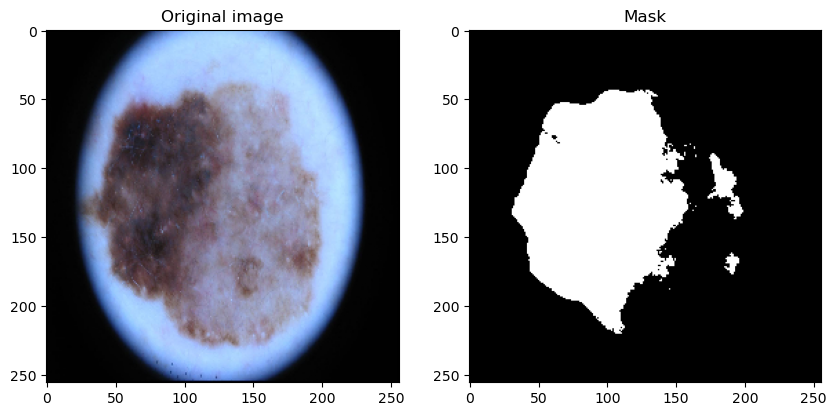

In [117]:
path = './ISIC/Test/melanoma/ISIC_0000036.jpg'
mask = segmentate(path, model)

In [53]:
# Extracción de características se regirá por la regla ABCD
# A Asimetría
# B Borde
# C Color
# D diámetro

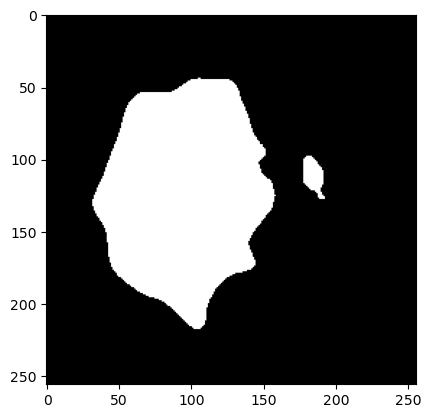

In [118]:
# Apply blur to the mask
# kernel = np.ones((15,15), np.uint8)

# morph_op = cv.morphologyEx(mask, cv.MORPH_DILATE, kernel, iterations=2)
# morph_op = cv.morphologyEx(morph_op, cv.MORPH_ERODE, kernel, iterations=2)
blur_mask = cv.blur(mask, (15,15))
plt.imshow(blur_mask, cmap='gray')

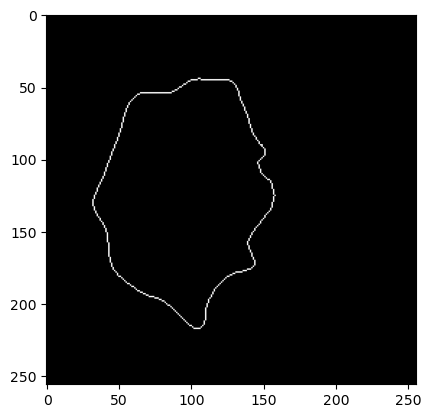

In [119]:
(h,w) = mask.shape[:2]
mask_contours = np.zeros((h,w))
edges = cv.Canny(blur_mask, 100, 200)

contours, hierarchy = cv.findContours(blur_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

contour_max = max(contours, key=cv.contourArea)

cv.drawContours(mask_contours, [contour_max], -1, 255)
plt.imshow(mask_contours, cmap='gray')

El diametro es: 174


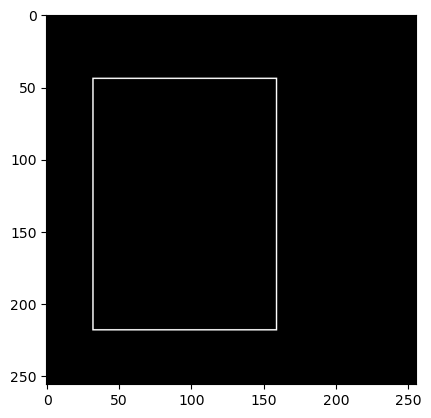

In [120]:
mask_bounding_rectangle = np.zeros((h,w))
x,y,w,h = cv.boundingRect(contour_max)
cv.rectangle(mask_bounding_rectangle, (x,y), (x+w, y+h), 255)
plt.imshow(mask_bounding_rectangle, cmap='gray')
diameter = max(w,h)
print(f"El diametro es: {diameter}")

In [121]:
# Borde
# Para esto calculamos circularidad
# Necesitamos área y el perimetro anteriormente calculado
perimeter = cv.arcLength(contour_max, True)
area = cv.contourArea(contour_max)

if perimeter > 0:
    circularity = ((4*math.pi*area)/(perimeter*perimeter))


print(circularity)


0.7026400944652991
